# Salinity Correction for SG266's RBR Legato3 Sensor Drift 
*March 2025 Deployment*
---
**Overview:**
- [x] Loop through each individual NetCDF file in the directory and extract the salinity data.
- [x] Calculate a linear fit for the selected drift region.
    - [x] Limit data used for linear fit to deep, offshore water only.
    - [x] Used SG686's salinity data as reference for the linear fit.
- [x] Apply the salinity correction formula to the extracted salinity data and create new NetCDF files with the corrected salinity data.

In [12]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [ ]:
# Directory containing dive files
dive_dir = r"C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives"
dive_files = sorted(glob.glob(f"{dive_dir}\\p266*.nc"))

# Create lists to hold concatenated data
time_list = []
sal_list = []
depth_list = []
lon_list = []

# Loop through each dive file and extract relevant data
for f in dive_files:
    print(f'Processing file {f}....')
    ds = xr.open_dataset(f, drop_variables=['compass_timeouts_times_truck'])

    time = ds['ctd_time'].values
    time_int = time.astype('int64') / 1e9 / 86400  # days
    depth = ds['ctd_depth'].values
    sal = ds['salinity'].values
    lon = ds['longitude'].values

    time_list.append(time_int)
    sal_list.append(sal)
    depth_list.append(depth)
    lon_list.append(lon)

    ds.close()

# Concatenate all data into single arrays
time_all = np.concatenate(time_list)
sal_all = np.concatenate(sal_list)
depth_all = np.concatenate(depth_list)
lon_all = np.concatenate(lon_list)


# Convert time from days since epoch to datetime64
time_date_all = (time_all * 86400 * 1e9).astype('datetime64[ns]')

# Create masks for filtering data
after_june_mask = time_date_all >= np.datetime64('2025-06-01')
before_june_mask = time_date_all < np.datetime64('2025-06-01')
exclude_mask = ~(
    (time_date_all >= np.datetime64('2025-08-31')) &
    (time_date_all <= np.datetime64('2025-10-01'))
)

depth_mask = (depth_all >= 900) & (depth_all <= 950)
lon_mask = (lon_all >= -129) & (lon_all <= -127)
sal_mask = ~np.isnan(sal_all)
time_mask = ~np.isnan(time_all)

# Mask to use for fitting
mask_fit = (
    after_june_mask &
    exclude_mask &
    depth_mask &
    lon_mask &
    sal_mask &
    time_mask
)

# Mask to use for pre-June data
pre_june_mask = (
    before_june_mask &
    depth_mask &
    lon_mask &
    sal_mask &
    time_mask
)

# Data for fitting
time_fit = time_all[mask_fit]
sal_fit = sal_all[mask_fit]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(time_fit, sal_fit)

# Load SG686 data for mean calculation
ds_686 = xr.open_dataset(r"C:\Users\marqjace\seaglider\sg686\TH_Line_11Nov25\sg686_2025_11_11_SG686_TH_Line_timeseries.nc", drop_variables=['compass_timeouts_times_truck'])

sg686_salinity = ds_686['salinity'].values
sg686_time = ds_686['ctd_time'].values
sg686_depth = ds_686['ctd_depth'].values
sg686_lon = ds_686['longitude'].values

sg686_time_int = sg686_time.astype('int64') / 1e9 / 86400

sg686_mask = (
    (sg686_depth >= 900) &
    (sg686_depth <= 950) &
    (sg686_lon >= -129) &
    (sg686_lon <= -127) &
    ~np.isnan(sg686_salinity)
)

# Calculate mean salinity before June 2025
sg266_before = sal_all[pre_june_mask]
sg686_before = sg686_salinity[sg686_mask]

mean_before = np.nanmean(
    np.concatenate([sg266_before, sg686_before])
)

def apply_salinity_drift(time_days, sal, slope, intercept, mean_before):

    # Convert to datetime ONLY for masking
    time_dt = (
        np.datetime64('1970-01-01')
        + time_days.astype('timedelta64[D]')
    )

    after_june = time_dt >= np.datetime64('2025-06-01')
    valid = after_june & ~np.isnan(sal)

    sal_corr = sal.copy()
    sal_corr[valid] = (
        sal[valid]
        - (slope * time_days[valid] + intercept)
        + mean_before
    )

    return sal_corr

# Create output directory
out_dir = r"C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives_salinity_corrected"
os.makedirs(out_dir, exist_ok=True)

# Apply correction and save new files
for f in dive_files:
    print(f'Correcting and saving file {os.path.basename(f)}....')
    ds = xr.open_dataset(f, drop_variables=['compass_timeouts_times_truck'])

    time_days = ds['ctd_time'].values.astype('int64') / 1e9 / 86400

    sal_corr = apply_salinity_drift(
        time_days,
        ds['salinity'].values,
        slope,
        intercept,
        mean_before
    )

    ds['salinity_corrected'] = (ds['salinity'].dims, sal_corr)
    ds['salinity_corrected'].attrs = ds['salinity'].attrs.copy()
    ds['salinity_corrected'].attrs['comment'] = (
        'Salinity drift corrected using linear fit from all SG266 dives'
    )
    
    out_file = os.path.join(out_dir, os.path.basename(f))
    ds.to_netcdf(out_file)
    ds.close()

Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660001.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660002.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660003.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660004.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660005.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660006.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660007.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660008.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660009.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660010.nc....
Processing file C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives\p2660011.nc....
Processing file C:\Us

Processing file p2660001.nc....
Processing file p2660002.nc....
Processing file p2660003.nc....
Processing file p2660004.nc....
Processing file p2660005.nc....
Processing file p2660006.nc....
Processing file p2660007.nc....
Processing file p2660008.nc....
Processing file p2660009.nc....
Processing file p2660010.nc....
Processing file p2660011.nc....
Processing file p2660012.nc....
Processing file p2660013.nc....
Processing file p2660014.nc....
Processing file p2660015.nc....
Processing file p2660016.nc....
Processing file p2660017.nc....
Processing file p2660018.nc....
Processing file p2660019.nc....
Processing file p2660020.nc....
Processing file p2660021.nc....
Processing file p2660022.nc....
Processing file p2660023.nc....
Processing file p2660024.nc....
Processing file p2660025.nc....
Processing file p2660026.nc....
Processing file p2660027.nc....
Processing file p2660028.nc....
Processing file p2660029.nc....
Processing file p2660030.nc....
Processing file p2660031.nc....
Processi

c:\Users\marqjace\AppData\Local\anaconda3\envs\th_line\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


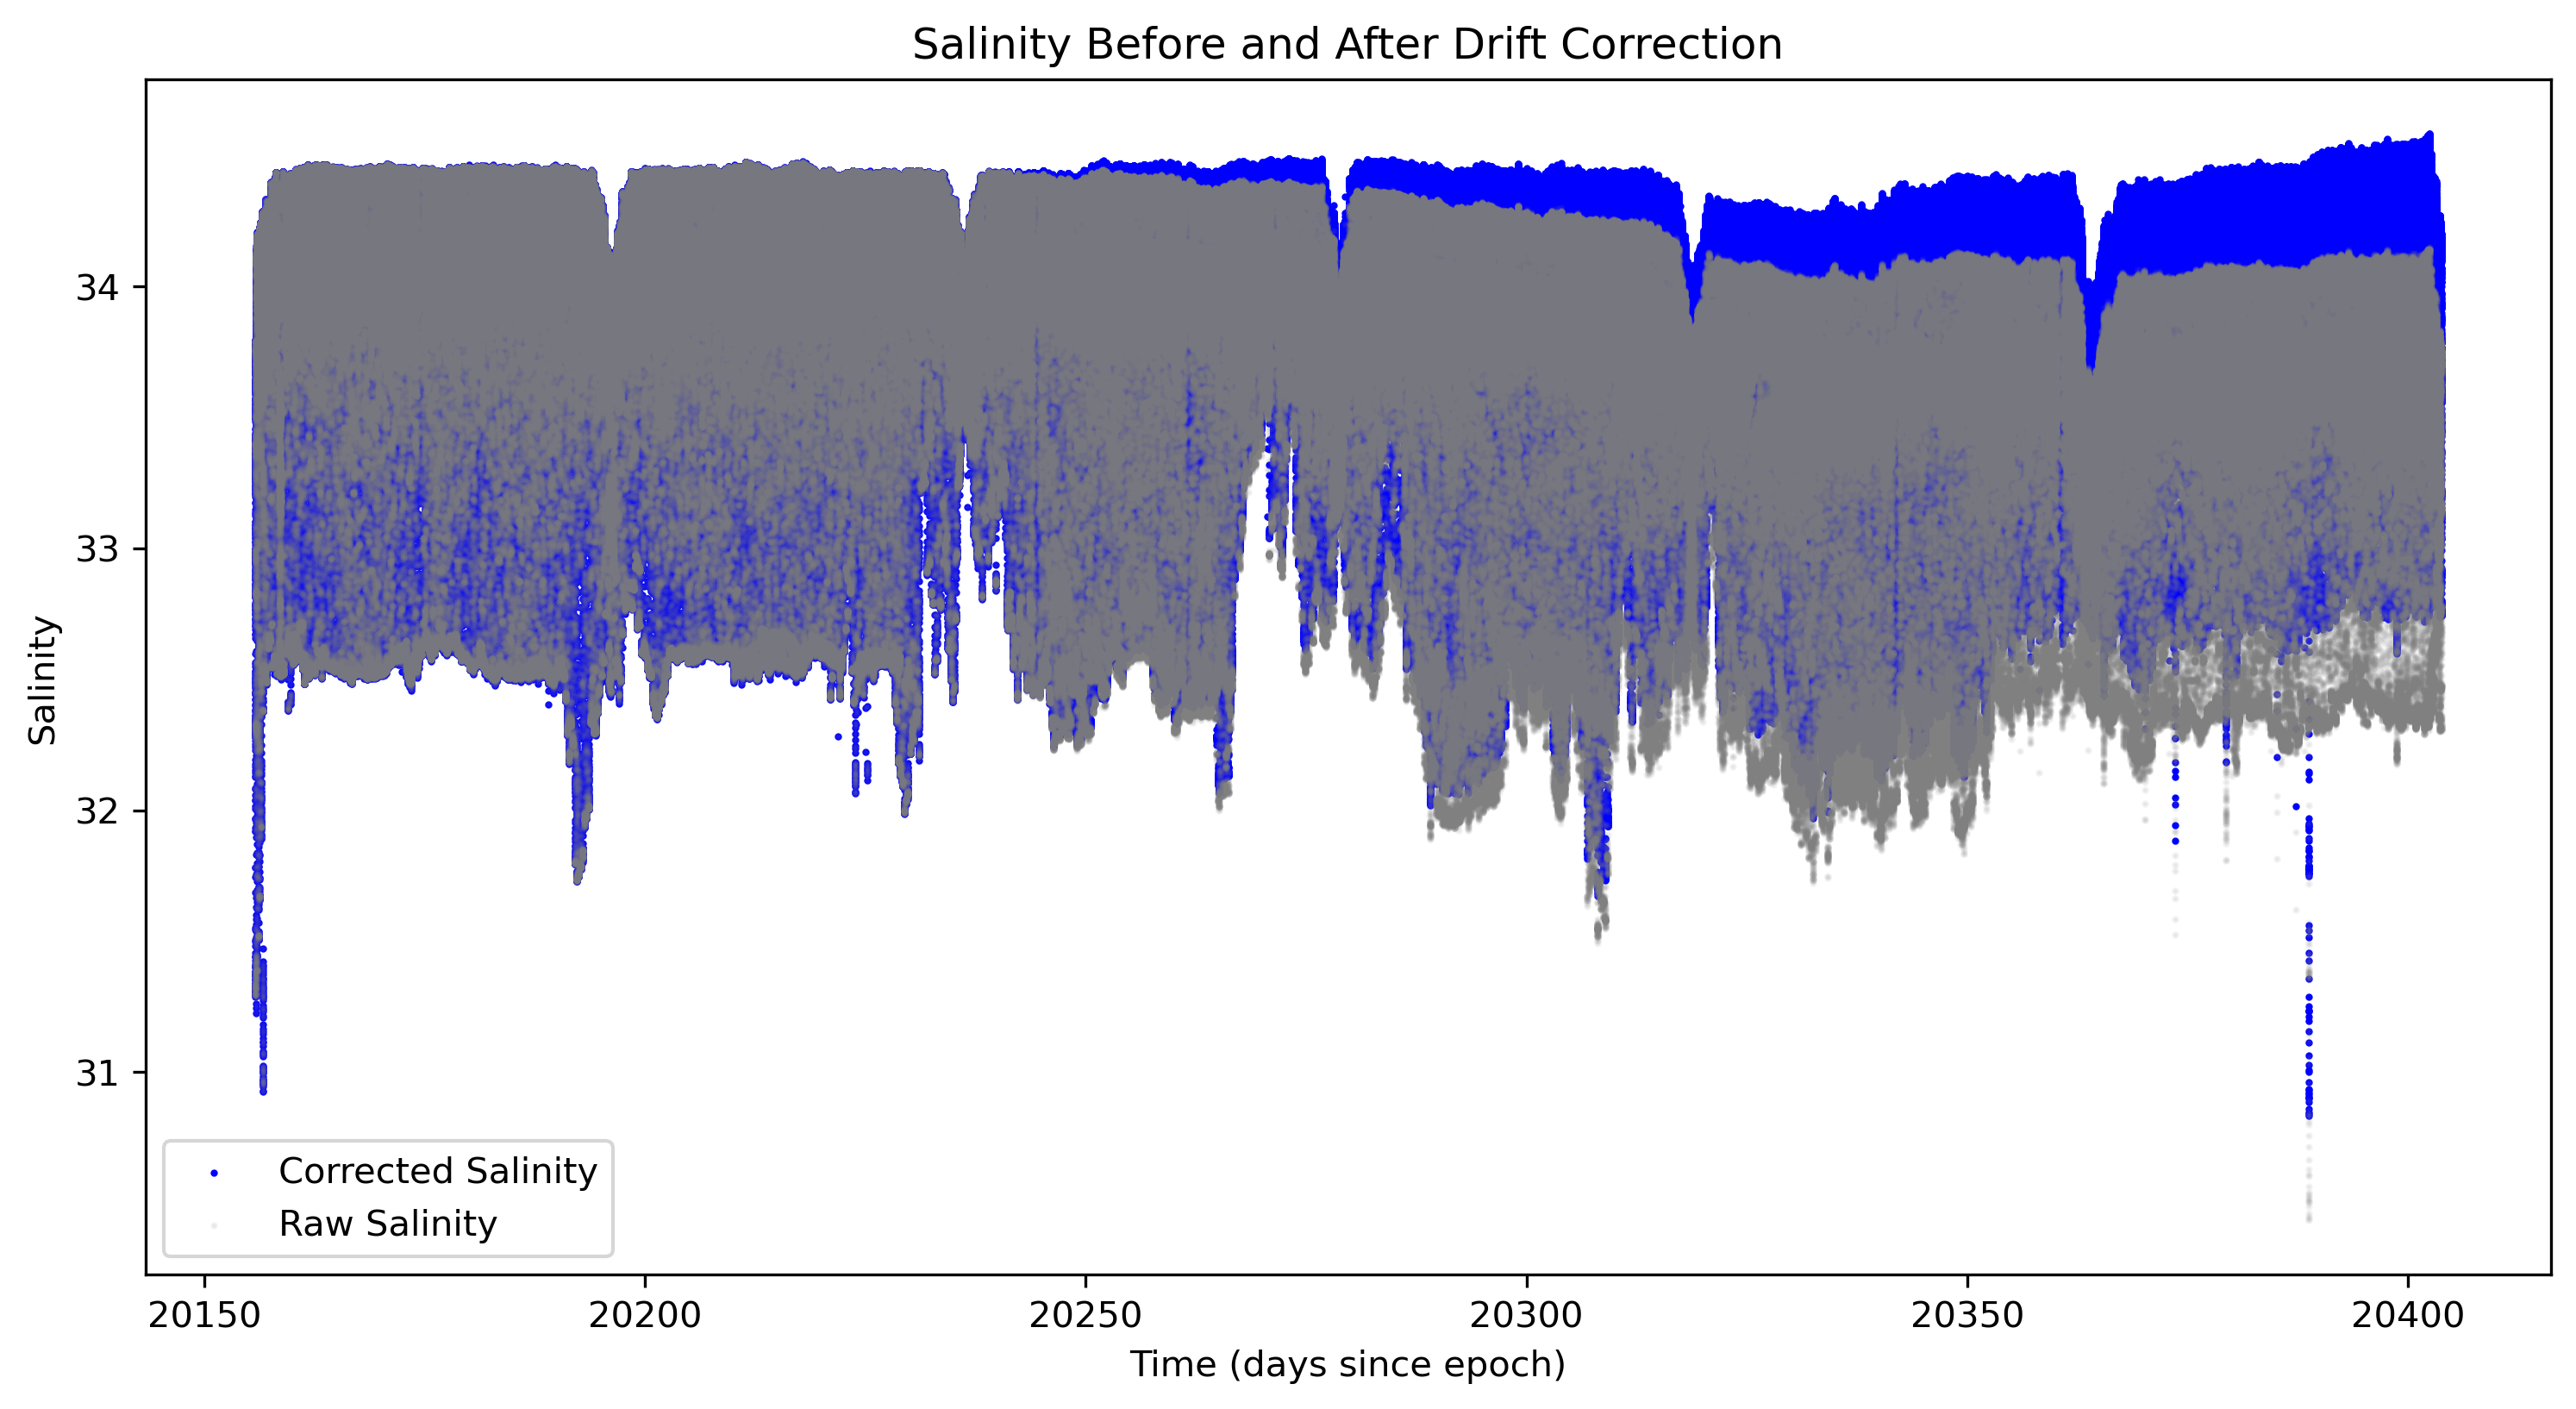

In [ ]:
dive_dir = r"C:\Users\marqjace\TH_line\deployments\mar_2025\all_dives_salinity_corrected"
dive_files = sorted(glob.glob(f"{dive_dir}\\p266*.nc"))

# Create lists to hold concatenated data
time_list = []
sal_list = []
sal_corr_list = []
depth_list = []
lon_list = []

# Loop through each dive file and extract relevant data
for f in dive_files:
    print(f'Processing file {os.path.basename(f)}....')
    ds = xr.open_dataset(f, drop_variables=['compass_timeouts_times_truck'])

    time = ds['ctd_time'].values
    time_int = time.astype('int64') / 1e9 / 86400  # days
    depth = ds['ctd_depth'].values
    sal = ds['salinity'].values
    sal_corr = ds['salinity_corrected'].values
    lon = ds['longitude'].values

    time_list.append(time_int)
    sal_list.append(sal)
    sal_corr_list.append(sal_corr)
    depth_list.append(depth)
    lon_list.append(lon)

    ds.close()

time_all = np.concatenate(time_list)
sal_all = np.concatenate(sal_list)
sal_corr_all = np.concatenate(sal_corr_list)
depth_all = np.concatenate(depth_list)
lon_all = np.concatenate(lon_list)

plt.subplots(figsize=(12, 6), dpi=300)
plt.scatter(time_all, sal_corr_all, s=1, color='blue', label='Corrected Salinity')
plt.scatter(time_all, sal_all, s=1, color='gray', label='Raw Salinity', alpha=0.1)
plt.xlabel('Time (days since epoch)')
plt.ylabel('Salinity')
plt.title('Salinity Before and After Drift Correction')
plt.legend()
plt.show()